# VGG19 Benchmark

In [1]:
model_name = "VGG19"

import torch
from torch import nn
from torchvision import models
# import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def compile_str(mlir):
    return iree.runtime.load_vm_flatbuffer(
        iree.compiler.compile_str(
            mlir, input_type="tosa", target_backends=["llvm-cpu"],
            extra_args=[
                "--iree-llvmcpu-target-cpu-features=host",
                "--iree-stream-partitioning-favor=max-concurrency",
                "--iree-flow-zero-fill-empty-tensors",
                "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
                "--iree-opt-const-eval",
                "--iree-opt-const-expr-hoisting",
                "--iree-opt-numeric-precision-reduction",
                "--iree-opt-strip-assertions"
            ]
        ),
        backend="llvm-cpu"
    )

def compile_file(filename):
    with open(filename) as f:
        return compile_str(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

## Prepare

In [2]:
MAGIC_NUM = 7777e-5

model = models.vgg19()
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
# model = torch.compile(model, backend="inductor")

recompute, storeall = [
    compile_file(x) for x in ["../recompute.mlir", "../storeall.mlir"]
]

## Experimental

In [3]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = model(image)
grad = torch.randn_like(output)

image_np = image.detach().numpy()
grad_np = grad.numpy()

df = pd.DataFrame()

### PyTorch (Baseline)

In [4]:
baseline_f = timeit("model(image)")
baseline_b = timeit("torch.autograd.grad(output, [image], grad, retain_graph=True)")
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch 1.8")])

### Nabla without Optim

In [5]:
f = timeit("recompute.forward(image_np)")
b = timeit("recompute.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla")])

### Nabla with Optim

In [6]:
f = timeit("storeall.forward(image_np)")
b = timeit("storeall.dforward(grad_np)")
df = pd.concat([df, get_dataframe(f, b, "Nabla Optim")])

## Result

In [7]:
df.to_csv(f"{model_name}-time.csv")
df.style.hide(axis="index")

time,pass,item
83.200415,Forward,Torch 1.8
204.509665,Backward,Torch 1.8
287.710080,Full,Torch 1.8
129.360347,Forward,Nabla
162.581921,Backward,Nabla
291.942269,Full,Nabla
154.173234,Forward,Nabla Optim
26.786328,Backward,Nabla Optim
180.959561,Full,Nabla Optim


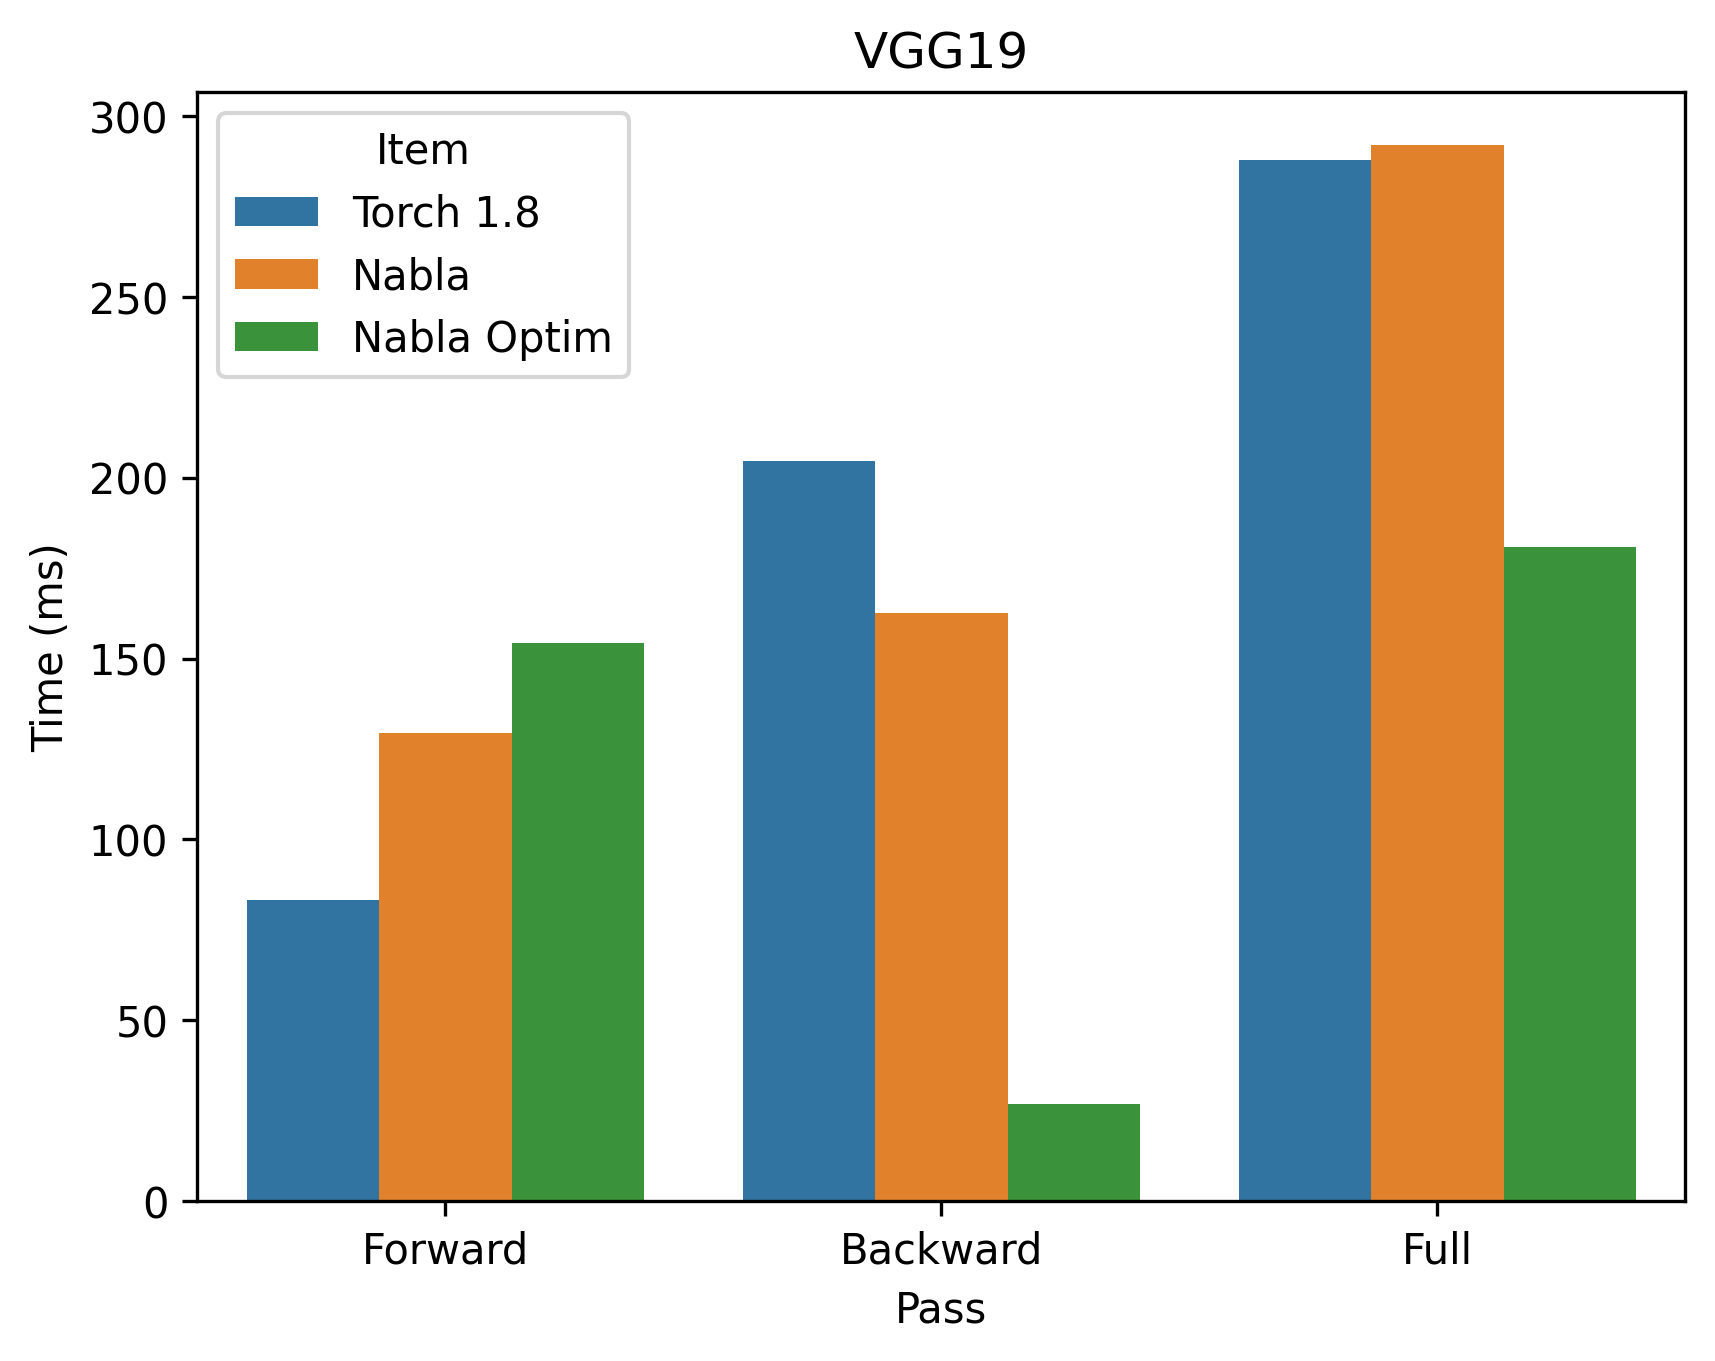

In [8]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [9]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,83.200415,Forward,Torch 1.8,1.000000
0,129.360347,Forward,Nabla,0.643168
0,154.173234,Forward,Nabla Optim,0.539655


In [10]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,204.509665,Backward,Torch 1.8,1.000000
0,162.581921,Backward,Nabla,1.257887
0,26.786328,Backward,Nabla Optim,7.634853


In [11]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,287.710080,Full,Torch 1.8,1.000000
0,291.942269,Full,Nabla,0.985503
0,180.959561,Full,Nabla Optim,1.589914


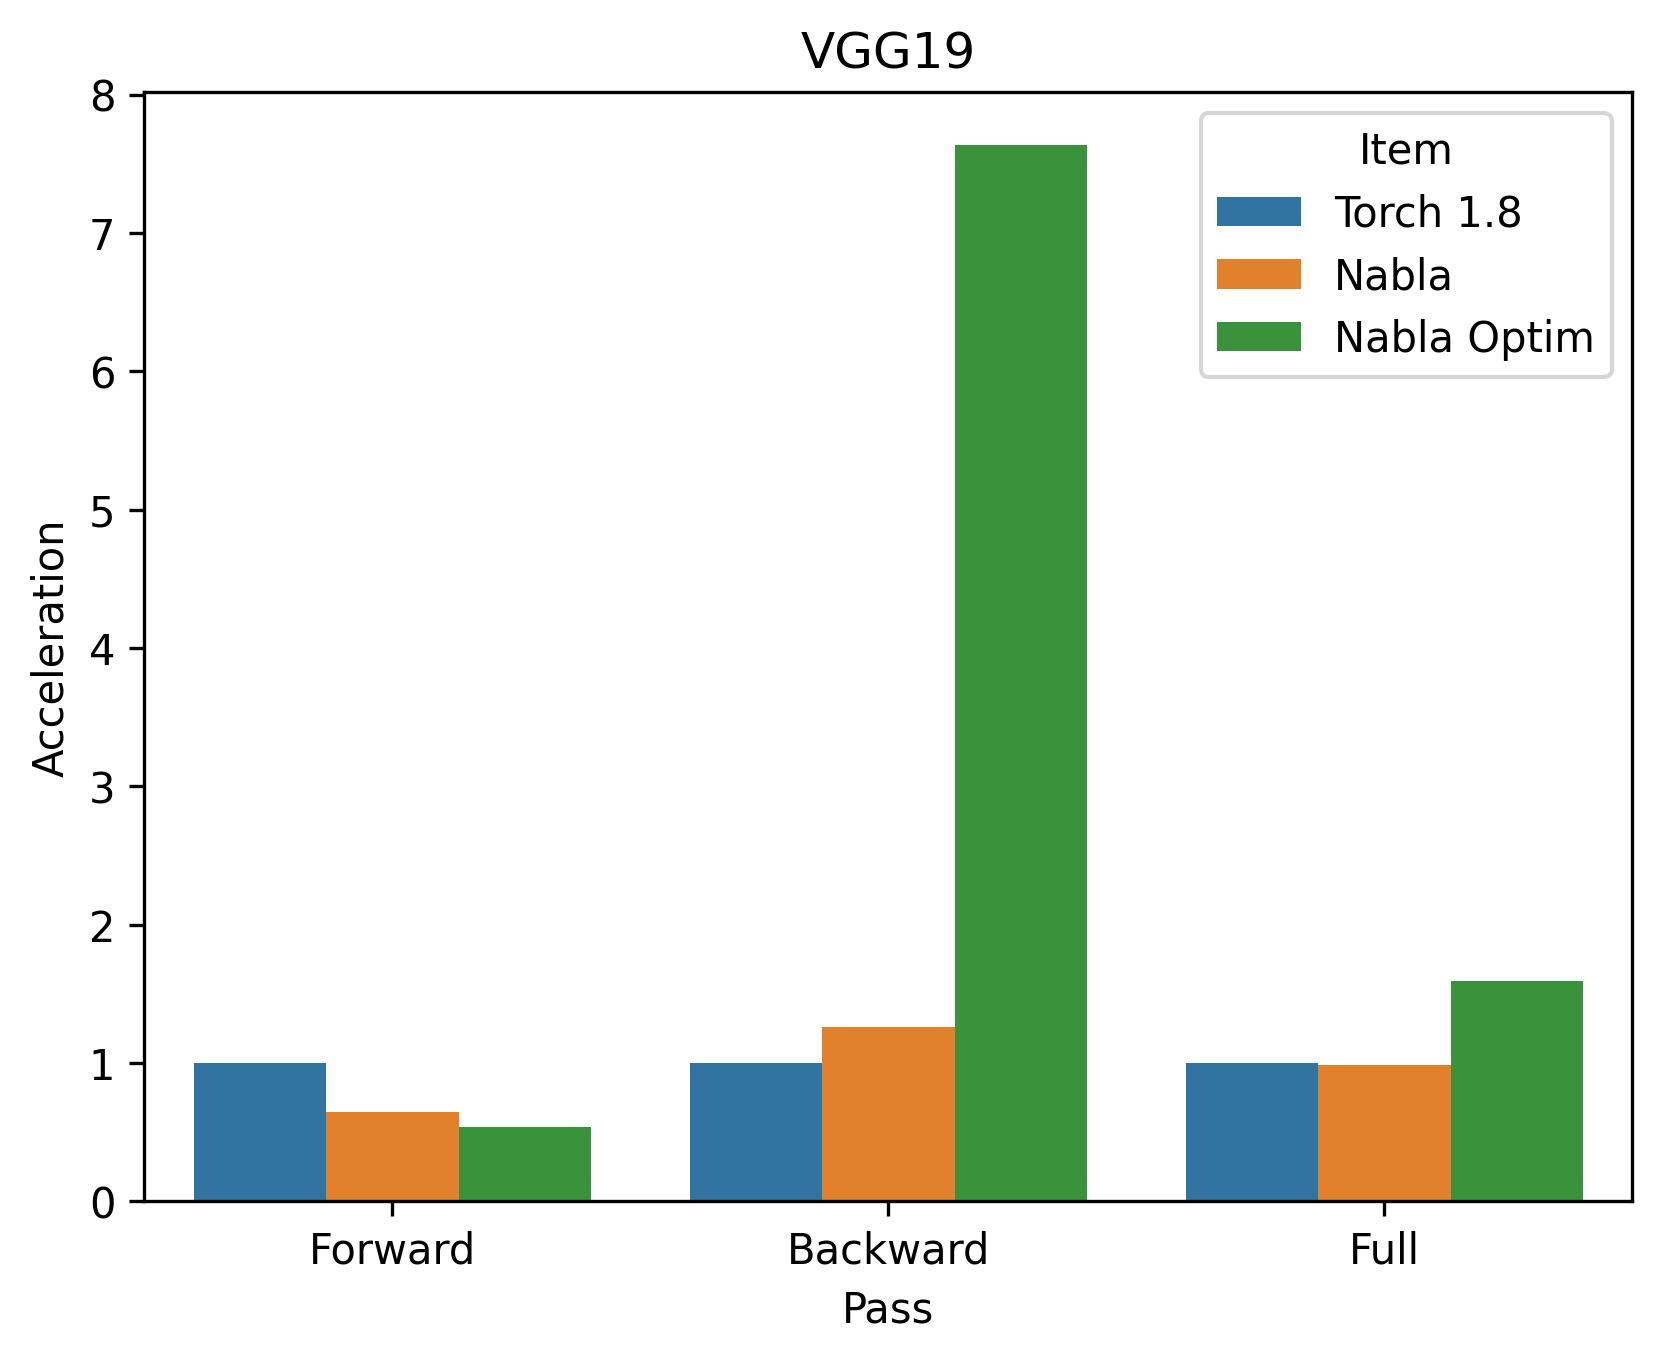

In [12]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}-acceleration.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")